# This notebook shows how to compute forces, relax atomic positions, and get the effective mass and charge density of bulk silicon
### Import the necessary libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from elkpy.structure import Structure

SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

structure = Structure(SI_AVEC, SI_SPECIES)
calc = structure.get_calculation("_scratch/si", xc="PW", ngridk=(2, 2, 2)) # cached ground state

### Hellmann-Feynman forces
$$ \mathbf F_I=-\frac{\partial E[n]}{\partial \mathbf R_I} $$
zero for an atom already at its equilibrium position.

In [2]:
forces = calc.get_forces() # Ha/Bohr, one row per atom
print(forces)

[[ 0.  0.  0.]
 [-0. -0. -0.]]


### Structural relaxation
Minimizing $E[n]$ over the atomic positions $\{\mathbf R_I\}$, i.e. following $\mathbf F_I$ to $\mathbf F_I=0$.

In [3]:
relaxed = calc.get_relaxed(workdir="_scratch/si_relaxed")
print(calc.get_energy(), relaxed.get_energy()) # already at equilibrium -> barely moves

-577.98351598716 -577.98351599083


### Effective mass tensor
$$ \left(\frac1{m^*}\right)_{ab}=\frac1{\hbar^2}\frac{\partial^2\epsilon(\mathbf k)}{\partial k_a\,\partial k_b} $$
isotropic at $\Gamma$ here by the cubic symmetry of the diamond lattice.

In [4]:
state = calc.get_effective_mass((0.0, 0.0, 0.0))[0]
print(state["tensor"])

[[ 1.15497805e+00 -7.59222218e-09 -7.59239991e-09]
 [-7.59222218e-09  1.15497805e+00 -7.59399199e-09]
 [-7.59239991e-09 -7.59399199e-09  1.15497805e+00]]


### Charge density
$$ n(\mathbf r)=\sum_i^{\rm occ}|\psi_i(\mathbf r)|^2 $$

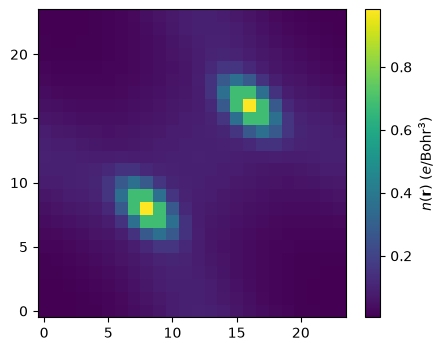

In [5]:
points, density = calc.get_density(grid=(24, 24, 24))
grid = density.reshape(24, 24, 24)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(grid[:, :, 12].T, origin="lower", cmap="viridis")
fig.colorbar(im, ax=ax, label=r"$n(\mathbf{r})$ ($e$/Bohr$^3$)")
plt.show()

### L, S and J expectation values, via the run_tasks() escape hatch
$$ \langle \hat L\rangle,\ \langle \hat S\rangle,\ \langle \hat J\rangle \ \text{for a chosen Bloch state} $$
any Elk task without a named wrapper is reachable through `run_tasks()`.

In [6]:
subdir = calc.run_tasks([15], blocks={"kstlist": [[1, 1]]}) # task 15: L, S, J
print((subdir / "LSJ.OUT").read_text())


Expectation values are computed only over the muffin-tin

Species : 1 (Si)
 atom : 1
  L :   0.1580991313E-17  0.2467127626E-18  0.1822814902E-17
  S :    0.000000000       0.000000000       0.000000000    
  J :   0.1580991313E-17  0.2467127626E-18  0.1822814902E-17
 atom : 2
  L :   0.1580991313E-17  0.2467127626E-18  0.1866860616E-17
  S :    0.000000000       0.000000000       0.000000000    
  J :   0.1580991313E-17  0.2467127626E-18  0.1866860616E-17

